In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


**Task-1:**

Found 90 files belonging to 6 classes.
Using 72 files for training.
Found 90 files belonging to 6 classes.
Using 18 files for validation.
Epoch 1/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 25s 5s/step - accuracy: 0.1389 - loss: 11.9028 - val_accuracy: 0.2222 - val_loss: 2.0315
Epoch 2/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step - accuracy: 0.3056 - loss: 11.7902 - val_accuracy: 0.1667 - val_loss: 2.2061
Epoch 3/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 7s 2s/step - accuracy: 0.5278 - loss: 6.8940 - val_accuracy: 0.0556 - val_loss: 2.5715
Epoch 4/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step - accuracy: 0.5139 - loss: 5.2294 - val_accuracy: 0.1667 - val_loss: 3.4490
Epoch 5/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step - accuracy: 0.6111 - loss: 4.2370 - val_accuracy: 0.1111 - val_loss: 5.2373
Epoch 6/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 7s 2s/step - accuracy: 0.6389 - loss: 3.5807 - val_accuracy: 0.0556 - val_loss: 7.2864
Epoch 7/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 1s/step - accuracy: 0.5556 - loss: 3.6535 - val_accuracy: 0.1111 - val_loss: 9.879

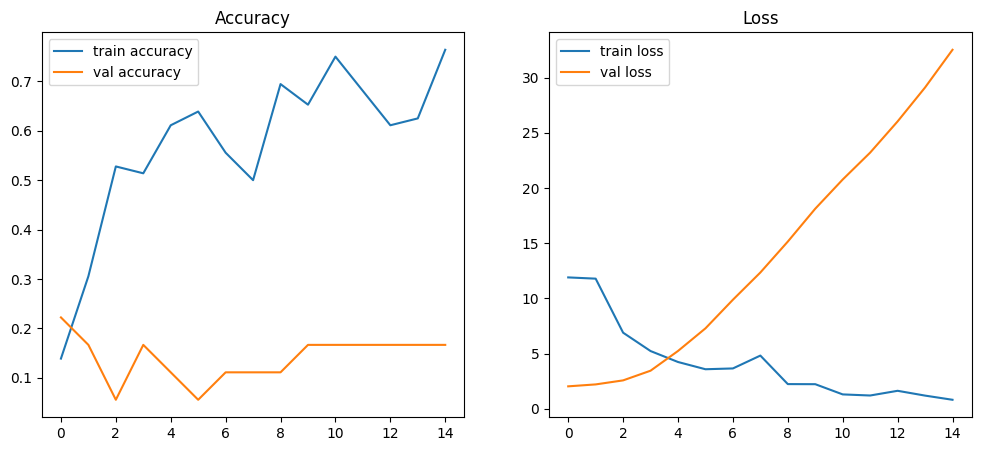

In [2]:
import tensorflow as tf
from tensorflow.keras import layers, models

# Dataset path
train_dir = "/content/drive/MyDrive/AI(6)/Week6/FruitinAmazon/train"

# Parameters
img_height = 128
img_width = 128
batch_size = 32
validation_split = 0.2

# Data Augmentation
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2),
])

# Rescaling
rescale = layers.Rescaling(1./255)

# Load dataset
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    validation_split=validation_split,
    subset="training",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    validation_split=validation_split,
    subset="validation",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

# Class info
class_names = train_ds.class_names
num_classes = len(class_names)

# Apply preprocessing
train_ds = train_ds.map(lambda x, y: (rescale(x), y))
val_ds = val_ds.map(lambda x, y: (rescale(x), y))

# Performance optimization
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

# Improved CNN Model
model = models.Sequential([
    tf.keras.Input(shape=(img_height, img_width, 3)),

    # Data Augmentation
    data_augmentation,

    # Block 1
    layers.Conv2D(32, (3,3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),
    layers.Dropout(0.25),

    # Block 2
    layers.Conv2D(64, (3,3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),
    layers.Dropout(0.25),

    # Block 3
    layers.Conv2D(128, (3,3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),
    layers.Dropout(0.3),

    # Classification
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(num_classes, activation='softmax')
])

# Compile
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Train
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15
)

# Plot Accuracy & Loss
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='train accuracy')
plt.plot(history.history['val_accuracy'], label='val accuracy')
plt.legend()
plt.title("Accuracy")

# Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.legend()
plt.title("Loss")

plt.show()

**Task- 2:**

In [3]:
import tensorflow as tf
import numpy as np
from tensorflow.keras.applications import VGG16
from tensorflow.keras import layers, models
from sklearn.metrics import classification_report

In [4]:
train_dir = "/content/drive/MyDrive/AI(6)/Week6/FruitinAmazon/train"

img_height = 224
img_width = 224
batch_size = 32
validation_split = 0.2

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    validation_split=validation_split,
    subset="training",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    validation_split=validation_split,
    subset="validation",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

class_names = train_ds.class_names
num_classes = len(class_names)

Found 90 files belonging to 6 classes.
Using 72 files for training.
Found 90 files belonging to 6 classes.
Using 18 files for validation.


In [5]:
rescale = layers.Rescaling(1./255)

train_ds = train_ds.map(lambda x, y: (rescale(x), y))
val_ds = val_ds.map(lambda x, y: (rescale(x), y))

In [6]:
base_model = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [7]:
for layer in base_model.layers:
    layer.trainable = False

In [8]:
base_model = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

In [9]:
for layer in base_model.layers:
    layer.trainable = False

In [10]:
x = base_model.output
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(1024, activation='relu')(x)
x = layers.Dense(num_classes, activation='softmax')(x)

In [11]:
model = models.Model(inputs=base_model.input, outputs=x)

In [12]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [13]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 74s 26s/step - accuracy: 0.1667 - loss: 1.9069 - val_accuracy: 0.1667 - val_loss: 1.9151
Epoch 2/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 60s 21s/step - accuracy: 0.4167 - loss: 1.5860 - val_accuracy: 0.3889 - val_loss: 1.8007
Epoch 3/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 52s 17s/step - accuracy: 0.5694 - loss: 1.3362 - val_accuracy: 0.4444 - val_loss: 1.6132
Epoch 4/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 81s 17s/step - accuracy: 0.6806 - loss: 1.1903 - val_accuracy: 0.3889 - val_loss: 1.5001
Epoch 5/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 52s 17s/step - accuracy: 0.7778 - loss: 1.0055 - val_accuracy: 0.4444 - val_loss: 1.4442
Epoch 6/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 52s 16s/step - accuracy: 0.7639 - loss: 0.9406 - val_accuracy: 0.5000 - val_loss: 1.4707
Epoch 7/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 52s 17s/step - accuracy: 0.8056 - loss: 0.8307 - val_accuracy: 0.5000 - val_loss: 1.4155
Epoch 8/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 51s 16s/step - accuracy: 0.8611 - loss: 0.7314 - val_accuracy: 0.5556 - val_loss: 1.3588


In [14]:
y_pred_probs = model.predict(val_ds)
y_pred = np.argmax(y_pred_probs, axis=1)

y_true = np.concatenate([y for x, y in val_ds], axis=0)

# Show some predictions
for i in range(10):
    print(f"Actual: {class_names[y_true[i]]} | Predicted: {class_names[y_pred[i]]}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 12s 12s/step
Actual: guarana | Predicted: graviola
Actual: pupunha | Predicted: guarana
Actual: guarana | Predicted: pupunha
Actual: pupunha | Predicted: cupuacu
Actual: guarana | Predicted: tucuma
Actual: cupuacu | Predicted: pupunha
Actual: pupunha | Predicted: graviola
Actual: tucuma | Predicted: guarana
Actual: guarana | Predicted: cupuacu
Actual: guarana | Predicted: guarana


In [15]:
report = classification_report(y_true, y_pred, target_names=class_names)
print("Classification Report:\n")
print(report)

Classification Report:

              precision    recall  f1-score   support

        acai       0.00      0.00      0.00         1
     cupuacu       0.00      0.00      0.00         2
    graviola       0.25      0.33      0.29         3
     guarana       0.20      0.20      0.20         5
     pupunha       0.00      0.00      0.00         4
      tucuma       0.50      0.33      0.40         3

    accuracy                           0.17        18
   macro avg       0.16      0.14      0.15        18
weighted avg       0.18      0.17      0.17        18



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
